In [50]:
import warnings
import gc
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from sklearn.ensemble import HistGradientBoostingRegressor
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.simplefilter("ignore", ConvergenceWarning)

## Загрузка данных и разведочный анализ (EDA)

In [51]:
df = pd.read_csv('data/taxi_pickups_area.csv', index_col=0, parse_dates=True)
print("Размер:", df.shape)
print("Период:", df.index.min(), "-", df.index.max())
print("Зон:", df.shape[1])
df.iloc[:3, :6]

Размер: (8064, 78)
Период: 2019-04-01 00:00:00 - 2019-06-23 23:45:00
Зон: 78


,Pickup Community Area_0,Pickup Community Area_1,Pickup Community Area_2,Pickup Community Area_3,Pickup Community Area_4,Pickup Community Area_5
Trip Start Timestamp,,,,,,
2019-04-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0
2019-04-01 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0
2019-04-01 00:30:00,0.0,0.0,0.0,0.0,0.0,0.0


In [52]:
# Структура спроса по зонам
col_mean = df.mean().sort_values(ascending=False)
print("Топ-5 зон по среднему спросу за 15 мин:")
print(col_mean.head().round(2).to_string())
print("\nПочти пустых зон (<0.05 в среднем):", int((col_mean < 0.05).sum()), "из", df.shape[1])
print("Средний спрос на ячейку:", round(df.values.mean(), 3))

Топ-5 зон по среднему спросу за 15 мин:
Pickup Community Area_8     83.93
Pickup Community Area_32    77.43
Pickup Community Area_76    30.33
Pickup Community Area_28    29.12
Pickup Community Area_0     15.75

Почти пустых зон (<0.05 в среднем): 19 из 78
Средний спрос на ячейку: 3.717


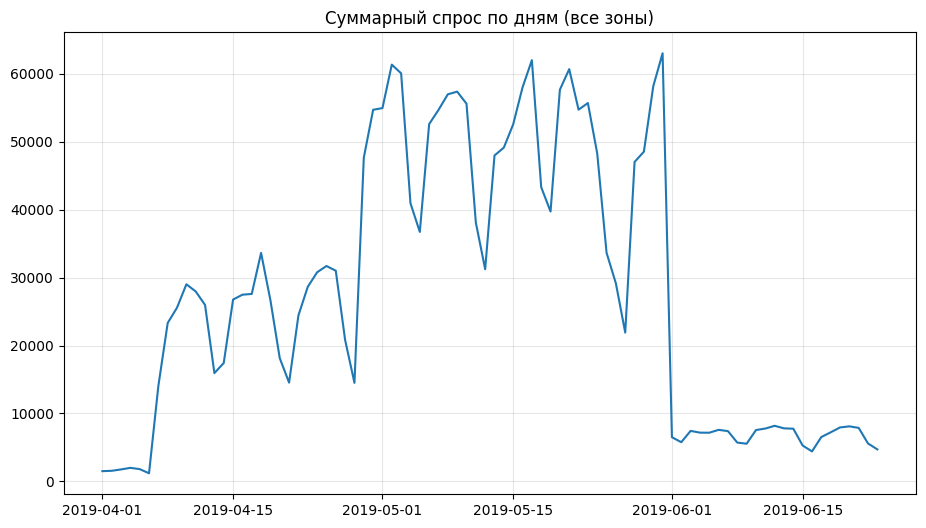

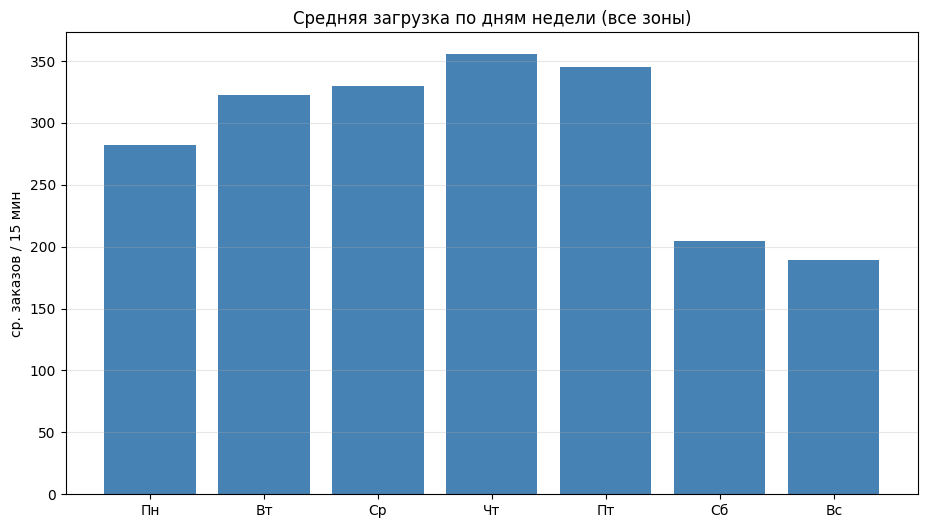

In [53]:
# Динамика суммарного дневного спроса — ищем структурные особенности
daily = df.sum(axis=1).resample("D").sum()
weekly = daily.resample("W").mean()

# Динамика спроса по дням
plt.figure(figsize=(11, 6))
plt.plot(daily.index, daily.values)
plt.title("Суммарный спрос по дням (все зоны)")
plt.grid(alpha=.3)

# по всей загрузке города (все зоны)
total = df.sum(axis=1)
by_dow = total.groupby(total.index.dayofweek).mean()

days = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']

plt.figure(figsize=(11, 6))
plt.bar(days, by_dow.values, color='steelblue')
plt.title('Средняя загрузка по дням недели (все зоны)')
plt.ylabel('ср. заказов / 15 мин')
plt.grid(alpha=.3, axis='y')
plt.show()

In [54]:
H = 672                       # горизонт прогноза = размер валидации
train = df.iloc[:-H]
valid = df.iloc[-H:]
Xtr, Xva = train.values, valid.values
print("train:", Xtr.shape, "| valid:", Xva.shape)
print("valid период:", valid.index.min(), "-", valid.index.max())

RECENT = 96 * 14             # «свежее окно» = 2 недели (полностью после структурного сдвига)

def mae(y_true, y_pred):
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))))

def postprocess(a):
    # спрос неотрицателен и целочислен
    return np.clip(np.round(a), 0, None)

results = {}   # дневник: метод -> (гиперпараметры, MAE)

train: (7392, 78) | valid: (672, 78)
valid период: 2019-06-17 00:00:00 - 2019-06-23 23:45:00


| Метод | Суть метода | Описание | Что улавливает | Ключевые гиперпараметры |
|---|---|---|---|---|
| Наивное среднее | Будущее = средний уровень всего прошлого. | Прогноз равен среднему прошлых значений ряда — одна константа на весь горизонт. | уровень | — |
| Скользящее среднее | Важно только недавнее прошлое, а не вся история. | Прогноз равен среднему за последнее окно из `w` наблюдений — константа на весь горизонт. | локальный уровень | размер окна `w` |
| SES | Чем свежее наблюдение, тем сильнее его вес. | Экспоненциально взвешенное среднее прошлых значений: недавние точки весомее. Прогноз плоский. | уровень | сглаживание `α` |
| Holt | Уровень, который еще и движется в каком-то направлении. | SES плюс линейный тренд — прогноз получает наклон. | уровень + тренд | `α`, `β` |
| Holt-Winters | Уровень + направление + повторяющийся периодический узор. | Holt плюс периодическая сезонная компонента — прогноз повторяет волну. | уровень + тренд + сезонность | `α`, `β`, `γ`, период |
| SARIMA | Ряд предсказывает сам себя — по своим прошлым значениям, ошибкам и их сезонным копиям. | Авторегрессия + скользящее среднее остатков + разности и их сезонные аналоги; лучшая модель — по AIC. | автокорреляция, тренд, сезонность | `(p,d,q)(P,D,Q,s)` |
| Сезонный профиль | Повторяем то, что обычно бывает в этот же момент цикла. | Среднее по группам «одинаковых моментов» (день недели × время суток); прогноз воспроизводит усредненный профиль. | суточная и недельная сезонность | длина окна, ключ группировки |
| HistGradientBoosting | Множество деревьев по очереди исправляют ошибки друг друга. | Ансамбль деревьев решений на табличных признаках; предсказывает целевое значение по признакам времени и категории. | нелинейные зависимости от признаков | число деревьев, глубина, learning rate |
| MLP | Сеть подбирает веса так, чтобы вход-признаки давали нужный выход. | Полносвязная нейросеть, отображающая входные признаки в выход; обучается градиентным спуском под выбранную функцию потерь. | гладкие нелинейные зависимости | архитектура, learning rate, число эпох, loss |

## 1. Наивные средние

In [55]:
# Среднее по всей истории
pred_all = np.tile(Xtr.mean(0), (H, 1))
mae_all = mae(Xva, postprocess(pred_all))

# Среднее по свежему окну
pred_rec = np.tile(Xtr[-RECENT:].mean(0), (H, 1))
mae_rec = mae(Xva, postprocess(pred_rec))

print(f"Наивное среднее (вся история)     MAE = {mae_all:.4f}")
print(f"Наивное среднее (свежие 2 недели) MAE = {mae_rec:.4f}")

results["1. Наивное (вся история)"] = ("mean по всем строкам", mae_all)
results["1. Наивное (свежее окно 2 нед)"] = (f"mean последних {RECENT} строк", mae_rec)

Наивное среднее (вся история)     MAE = 3.0543
Наивное среднее (свежие 2 недели) MAE = 0.6149


## 2. Скользящие средние

In [56]:
windows = [96, 288, 96*7, 96*14, 96*21, 96*28]  # 1д, 3д, 1нед, 2нед, 3нед, 4нед
ma_scores = {}
for w in windows:
    pred = np.tile(Xtr[-w:].mean(0), (H, 1))
    ma_scores[w] = mae(Xva, postprocess(pred))

for w, m in ma_scores.items():
    print(f"окно {w:5d} ({w//96:2d} дн)  MAE = {m:.4f}")

best_w = min(ma_scores, key=ma_scores.get)
print(f"\nЛучшее окно: {best_w} ({best_w//96} дн), MAE = {ma_scores[best_w]:.4f}")
results["2. Скользящее среднее"] = (f"window={best_w} ({best_w//96} дн)", ma_scores[best_w])

окно    96 ( 1 дн)  MAE = 0.6482
окно   288 ( 3 дн)  MAE = 0.6145
окно   672 ( 7 дн)  MAE = 0.6123
окно  1344 (14 дн)  MAE = 0.6149
окно  2016 (21 дн)  MAE = 1.3521
окно  2688 (28 дн)  MAE = 2.3734

Лучшее окно: 672 (7 дн), MAE = 0.6123


## 3. Экспоненциальное сглаживание

In [57]:
def forecast_ets(series_matrix, horizon, mode):
    # Прогноз ETS по каждой зоне отдельно. series_matrix: (T, n_zones)
    preds = []
    for j in range(series_matrix.shape[1]):
        y = np.maximum(series_matrix[:, j].astype(float), 0)
        try:
            if mode == "ses":
                m = SimpleExpSmoothing(y, initialization_method="estimated")
            elif mode == "holt":
                m = ExponentialSmoothing(y, trend="add", initialization_method="estimated")
            else:  # holt_winters
                m = ExponentialSmoothing(y, trend="add", damped_trend=True, seasonal="add",
                                         seasonal_periods=96, initialization_method="estimated")
            fit = m.fit(optimized=True)
            preds.append(fit.forecast(horizon))
        except Exception:
            preds.append(np.full(horizon, y.mean()))
    return np.stack(preds, axis=1)

recent_tr = Xtr[-RECENT:]
for mode, name in [("ses", "SES"), ("holt", "Holt"), ("holt_winters", "Holt-Winters(96)")]:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        p = postprocess(forecast_ets(recent_tr, H, mode))
    score = mae(Xva, p)
    print(f"{name:18s} MAE = {score:.4f}")
    results[f"3. Экс.сглаживание {name}"] = (f"optimized, окно={RECENT//96}дн", score)

SES                MAE = 0.7386
Holt               MAE = 0.8240
Holt-Winters(96)   MAE = 0.5261


## 4. SARIMA

In [58]:
grid = [
    ((1, 0, 1), (1, 0, 0, 96)),
    ((0, 1, 1), (1, 0, 0, 96)),
]
sarima_train = Xtr[-96*10:]     # 10 дней для скорости/памяти
MIN_MEAN = 1.0                  # зоны со средним ниже — считаем "пустыми" (fallback)
n_zones = Xtr.shape[1]

sarima_pred = np.zeros((H, n_zones))
t0 = time.time(); n_fit = 0
print(f"SARIMA по всем {n_zones} зонам (fit где спрос >= {MIN_MEAN}):\n")

for i in range(n_zones):
    tz = time.time()
    y = np.maximum(sarima_train[:, i].astype(float), 0)

    # почти пустые зоны: SARIMA бессмысленна и медленна -> дешевый fallback
    if y.mean() < MIN_MEAN:
        sarima_pred[:, i] = postprocess(np.full(H, Xtr[-RECENT:, i].mean()))
        print(f"[{i+1:2d}/{n_zones}] {df.columns[i]:26s} fallback (пустая)      "
              f"MAE={mae(Xva[:, i], sarima_pred[:, i]):6.3f}  {time.time()-tz:4.1f}s")
        continue

    # подбор лучшей SARIMA по AIC
    best = None
    for order, sorder in grid:
        try:
            fit = SARIMAX(y, order=order, seasonal_order=sorder,
                          enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
            aic, fc = fit.aic, postprocess(fit.forecast(H))
            if best is None or aic < best[0]:
                best = (aic, order, sorder, fc)
            del fit; gc.collect()
        except Exception:
            continue

    aic, order, sorder, fc = best
    sarima_pred[:, i] = fc; n_fit += 1
    el = time.time() - t0; eta = el / (i+1) * (n_zones - i - 1)
    print(f"[{i+1:2d}/{n_zones}] {df.columns[i]:26s} SARIMA {order}x{sorder} "
          f"AIC={aic:6.0f} MAE={mae(Xva[:, i], fc):6.3f}  {time.time()-tz:4.1f}s  ETA~{eta:4.0f}s")

full_mae = mae(Xva, sarima_pred)
print(f"\nSARIMA обучено на {n_fit} зонах, fallback на {n_zones - n_fit}.")
print(f"ОБЩЕЕ ВРЕМЯ: {time.time() - t0:.0f}s | MAE SARIMA по ВСЕМ {n_zones} зонам = {full_mae:.4f}")

results["4. SARIMA (best AIC, все 78 зон)"] = ("grid AIC, seas=96, fallback на пустых", full_mae)

SARIMA по всем 78 зонам (fit где спрос >= 1.0):

[ 1/78] Pickup Community Area_0    SARIMA (1, 0, 1)x(1, 0, 0, 96) AIC=  4203 MAE= 5.955  22.2s  ETA~1708s
[ 2/78] Pickup Community Area_1    fallback (пустая)      MAE= 0.268   0.0s
[ 3/78] Pickup Community Area_2    fallback (пустая)      MAE= 0.247   0.0s
[ 4/78] Pickup Community Area_3    fallback (пустая)      MAE= 0.696   0.0s
[ 5/78] Pickup Community Area_4    fallback (пустая)      MAE= 0.183   0.0s
[ 6/78] Pickup Community Area_5    fallback (пустая)      MAE= 0.126   0.0s
[ 7/78] Pickup Community Area_6    SARIMA (1, 0, 1)x(1, 0, 0, 96) AIC=  3557 MAE= 3.135  15.9s  ETA~ 386s
[ 8/78] Pickup Community Area_7    SARIMA (1, 0, 1)x(1, 0, 0, 96) AIC=  2999 MAE= 1.436  15.4s  ETA~ 468s
[ 9/78] Pickup Community Area_8    SARIMA (1, 0, 1)x(1, 0, 0, 96) AIC=  5515 MAE=19.479  14.7s  ETA~ 523s
[10/78] Pickup Community Area_9    fallback (пустая)      MAE= 0.006   0.0s
[11/78] Pickup Community Area_10   fallback (пустая)      MAE= 0.064   

## 5. Сезонный профиль (день недели x время суток)

In [59]:
def seasonal_key(index):
    return (index.dayofweek * 96 + index.hour * 4 + index.minute // 15).values

def seasonal_profile_forecast(history_df, target_index, window_days):
    sub = history_df.iloc[-96*window_days:]
    k = seasonal_key(sub.index)
    tmp = pd.DataFrame(sub.values); tmp["k"] = k
    prof = tmp.groupby("k").mean().reindex(range(7*96)).ffill().bfill().values
    return prof[seasonal_key(target_index)]

prof_scores = {}
for wd in [7, 10, 14, 21, 28]:
    p = postprocess(seasonal_profile_forecast(train, valid.index, wd))
    prof_scores[wd] = mae(Xva, p)
    print(f"окно {wd:2d} дн  MAE = {prof_scores[wd]:.4f}")

best_wd = min(prof_scores, key=prof_scores.get)
print(f"\nЛучшее окно профиля: {best_wd} дн, MAE = {prof_scores[best_wd]:.4f}")
results["5. Сезонный профиль (dow×tod)"] = (f"window={best_wd}дн", prof_scores[best_wd])

окно  7 дн  MAE = 0.4351
окно 10 дн  MAE = 0.4095
окно 14 дн  MAE = 0.3648
окно 21 дн  MAE = 1.4361
окно 28 дн  MAE = 2.3799

Лучшее окно профиля: 14 дн, MAE = 0.3648


## 6. Бонус ML

In [60]:
def make_features(index, n_zones):
    # Строит табличные признаки для всех (время × зона)
    slot = index.hour*4 + index.minute//15
    dow = index.dayofweek
    base = pd.DataFrame({
        "slot": slot, "dow": dow, "hour": index.hour,
        "is_weekend": (dow >= 5).astype(int),
    })
    # размножаем по зонам
    rep = pd.concat([base.assign(zone=z) for z in range(n_zones)], ignore_index=True)
    return rep

n_zones = Xtr.shape[1]
tr_recent = train.iloc[-RECENT:]
Xtab_tr = make_features(tr_recent.index, n_zones)
ytab_tr = tr_recent.values.reshape(-1, order="F")   # порядок совпадает с concat по зонам

gb = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.08,
                                   max_depth=6, categorical_features=["zone"],
                                   random_state=42)
gb.fit(Xtab_tr, ytab_tr)

Xtab_va = make_features(valid.index, n_zones)
pred_gb = gb.predict(Xtab_va).reshape(H, n_zones, order="F")
mae_gb = mae(Xva, postprocess(pred_gb))
print(f"HistGradientBoosting  MAE = {mae_gb:.4f}")
results["6. ML: HistGradientBoosting"] = ("300 деревьев, календарь+зона", mae_gb)

HistGradientBoosting  MAE = 0.3145


## 7. Бонус DL

In [61]:
def cal_vector(index):
    slot = index.hour*4 + index.minute//15
    dow = index.dayofweek
    return np.stack([
        slot / 95.0,               # время суток, нормировано
        dow / 6.0,                 # день недели, нормировано
        (dow >= 5).astype(float),  # выходной
    ], axis=1).astype(np.float32)

torch.manual_seed(42)
Ftr = torch.tensor(cal_vector(tr_recent.index))
Ytr = torch.tensor(tr_recent.values.astype(np.float32))

net = nn.Sequential(nn.Linear(3, 128), nn.ReLU(), nn.Linear(128, 128),
                    nn.ReLU(), nn.Linear(128, n_zones))
opt = torch.optim.Adam(net.parameters(), lr=5e-3)
loss_fn = nn.L1Loss()   # оптимизируем прямо MAE

for epoch in range(300):
    opt.zero_grad()
    loss = loss_fn(net(Ftr), Ytr)
    loss.backward(); opt.step()

net.eval()
with torch.no_grad():
    pred_dl = net(torch.tensor(cal_vector(valid.index))).numpy()
mae_dl = mae(Xva, postprocess(pred_dl))
print(f"MLP (78 зон)  MAE = {mae_dl:.4f}")
results["7. DL: MLP по календарю"] = ("MLP 3→128→128→78, L1, 300 эп", mae_dl)

MLP (78 зон)  MAE = 0.3556


## Итоговая таблица результатов

In [62]:
table = (pd.DataFrame([(k, v[0], v[1]) for k, v in results.items()],
                      columns=["Подход", "Гиперпараметры", "MAE (valid)"])
         .sort_values("MAE (valid)").reset_index(drop=True))
pd.set_option("display.max_colwidth", 60)
print(table.to_string(index=False))

best_name = table.iloc[0]["Подход"]
best_mae = table.iloc[0]["MAE (valid)"]
print(f"\nЛидер по MAE на валидации: {best_name}  (MAE={best_mae:.4f})")

                             Подход                        Гиперпараметры  MAE (valid)
        6. ML: HistGradientBoosting          300 деревьев, календарь+зона     0.314503
            7. DL: MLP по календарю          MLP 3→128→128→78, L1, 300 эп     0.355617
      5. Сезонный профиль (dow×tod)                           window=14дн     0.364755
3. Экс.сглаживание Holt-Winters(96)                  optimized, окно=14дн     0.526061
              2. Скользящее среднее                     window=672 (7 дн)     0.612256
     1. Наивное (свежее окно 2 нед)             mean последних 1344 строк     0.614927
             3. Экс.сглаживание SES                  optimized, окно=14дн     0.738629
            3. Экс.сглаживание Holt                  optimized, окно=14дн     0.823985
   4. SARIMA (best AIC, все 78 зон) grid AIC, seas=96, fallback на пустых     0.885665
           1. Наивное (вся история)                  mean по всем строкам     3.054258

Лидер по MAE на валидации: 6. ML: HistGrad

## Формирование прогноза

In [65]:
sub = pd.read_csv('data/taxi_submission_file.csv', index_col=0)
sub.index = pd.to_datetime(sub.index)
print("Прогнозный период:", sub.index.min(), "-", sub.index.max(), "| строк:", len(sub))

# сезонный профиль на всей истории, окно best_wd
final = seasonal_profile_forecast(df, sub.index, best_wd)
final = postprocess(final)

out = pd.DataFrame(final, index=sub.index, columns=sub.columns)
out.index.name = df.index.name
out.to_csv("data/taxi_submission_file.csv")

print("Файл сохранен: taxi_submission_file.csv", out.shape)
print("Пропусков:", int(out.isna().sum().sum()), "| отрицательных:", int((out.values < 0).sum()))
print("Диапазон значений:", out.values.min(), "…", out.values.max())
out.iloc[:3, :6]

Прогнозный период: 2019-06-24 00:00:00 - 2019-06-30 23:45:00 | строк: 672
Файл сохранен: taxi_submission_file.csv (672, 78)
Пропусков: 0 | отрицательных: 0
Диапазон значений: 0.0 … 54.0


,Pickup Community Area_0,Pickup Community Area_1,Pickup Community Area_2,Pickup Community Area_3,Pickup Community Area_4,Pickup Community Area_5
Trip Start Timestamp,,,,,,
2019-06-24 00:00:00,4.0,0.0,0.0,1.0,0.0,0.0
2019-06-24 00:15:00,4.0,0.0,0.0,0.0,0.0,0.0
2019-06-24 00:30:00,4.0,0.0,0.0,0.0,0.0,0.0
